<a href="https://www.kaggle.com/code/lalit7881/e-commerce-sales-analytics-eda?scriptVersionId=345813761" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/order_items.csv
/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/customer_master.csv
/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/ecommerce_sales_customer_analytics_150k.csv
/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/dataset_statistics.csv
/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/product_catalog.csv


## Loading dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/customer_master.csv')

In [3]:
df.head()

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53
3,CUST-000004,David Lopez,30,Male,VIP,Hawkinshaven,Pennsylvania,USA,East,53984,16.02
4,CUST-000005,Dakota Davis,55,Female,Consumer,New Carlymouth,Florida,USA,South,50994,41.34


In [4]:
df.tail()

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
24995,CUST-024996,Nathan Porter,40,Male,Consumer,Kristineport,Texas,USA,South,62079,14.92
24996,CUST-024997,Heather Graham,19,Female,Consumer,Ruizside,North Rhine,Germany,West,16488,11.41
24997,CUST-024998,John Smith,31,Female,Business,Jacksonside,North Carolina,USA,South,86726,66.95
24998,CUST-024999,Eric Castillo,52,Female,Consumer,West Brandonfort,Ontario,Canada,East,92053,24.97
24999,CUST-025000,Peter Everett,52,Male,Premium,Blankenshipburgh,Ohio,USA,Central,73417,52.38


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                25000 non-null  object 
 1   customer_name              25000 non-null  object 
 2   customer_age               25000 non-null  int64  
 3   gender                     25000 non-null  object 
 4   customer_segment           25000 non-null  object 
 5   customer_city              25000 non-null  object 
 6   customer_state             25000 non-null  object 
 7   customer_country           25000 non-null  object 
 8   region                     25000 non-null  object 
 9   customer_postal_code       25000 non-null  int64  
 10  customer_acquisition_cost  25000 non-null  float64
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


In [6]:
df.describe()

,customer_age,customer_postal_code,customer_acquisition_cost
count,25000.000000,25000.000000,25000.000000
mean,45.907840,50183.066400,42.159750
std,16.454286,28596.584321,21.692648
min,18.000000,516.000000,5.010000
25%,32.000000,25374.500000,23.297500
50%,46.000000,50303.000000,41.980000
75%,60.000000,74845.500000,61.130000
max,74.000000,99950.000000,79.990000


In [7]:
df.isnull().sum()

customer_id                  0
customer_name                0
customer_age                 0
gender                       0
customer_segment             0
customer_city                0
customer_state               0
customer_country             0
region                       0
customer_postal_code         0
customer_acquisition_cost    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

customer_id                   object
customer_name                 object
customer_age                   int64
gender                        object
customer_segment              object
customer_city                 object
customer_state                object
customer_country              object
region                        object
customer_postal_code           int64
customer_acquisition_cost    float64
dtype: object

In [10]:
df.shape

(25000, 11)

In [11]:
df.columns

Index(['customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code',
       'customer_acquisition_cost'],
      dtype='object')

In [12]:
df.nunique()

customer_id                  25000
customer_name                21631
customer_age                    57
gender                           3
customer_segment                 4
customer_city                15555
customer_state                  38
customer_country                 7
region                           5
customer_postal_code         22183
customer_acquisition_cost     7215
dtype: int64

In [13]:
df.dtypes

customer_id                   object
customer_name                 object
customer_age                   int64
gender                        object
customer_segment              object
customer_city                 object
customer_state                object
customer_country              object
region                        object
customer_postal_code           int64
customer_acquisition_cost    float64
dtype: object

## EDA


No missing values found.


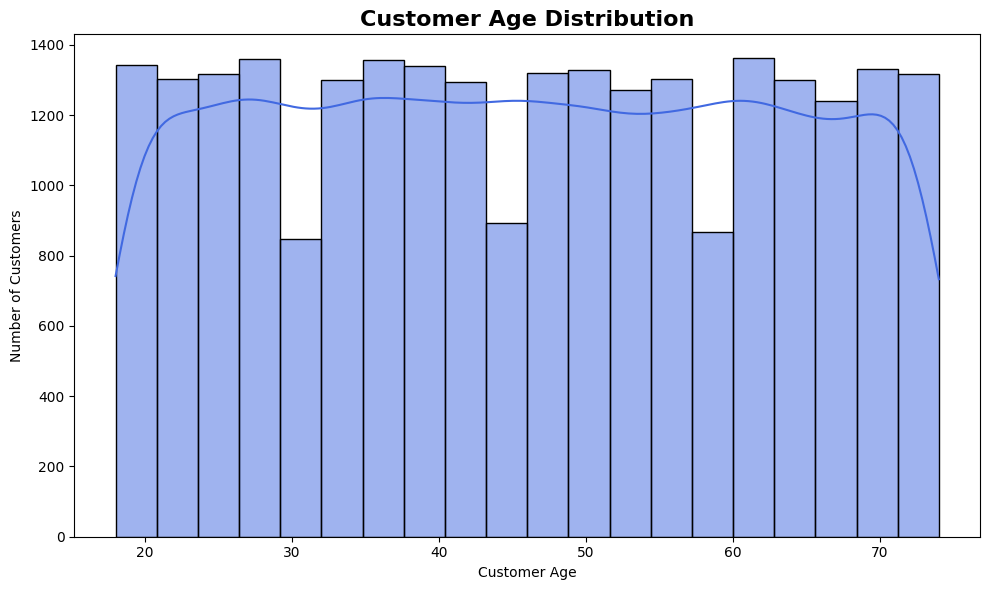

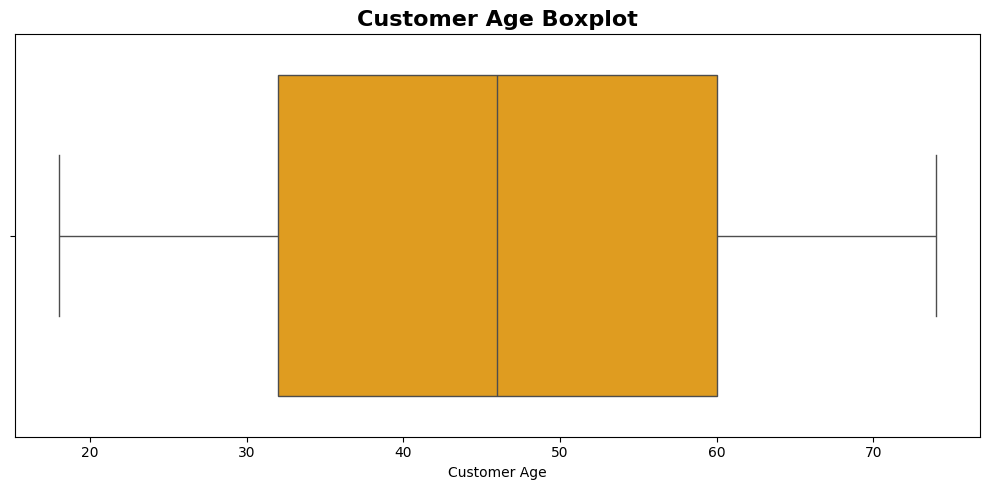

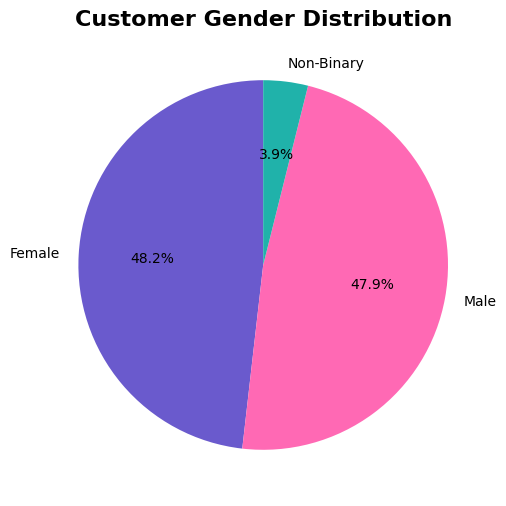

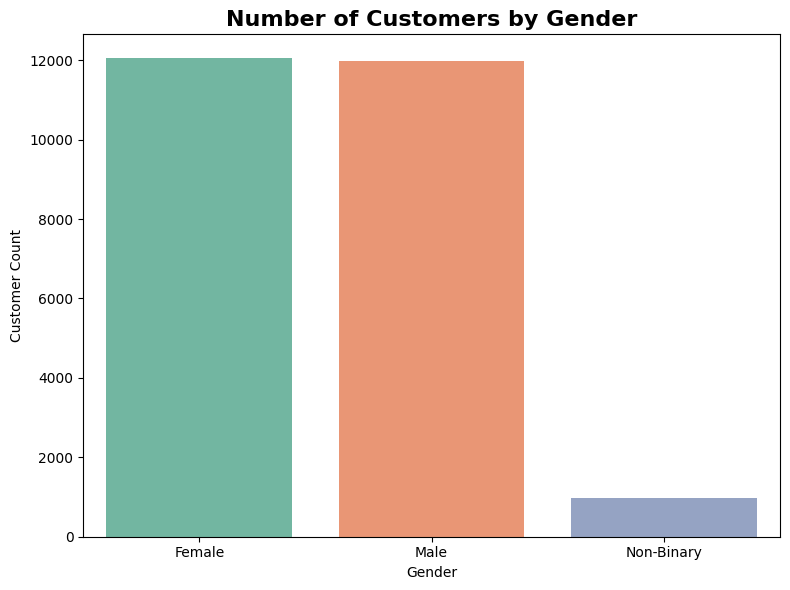

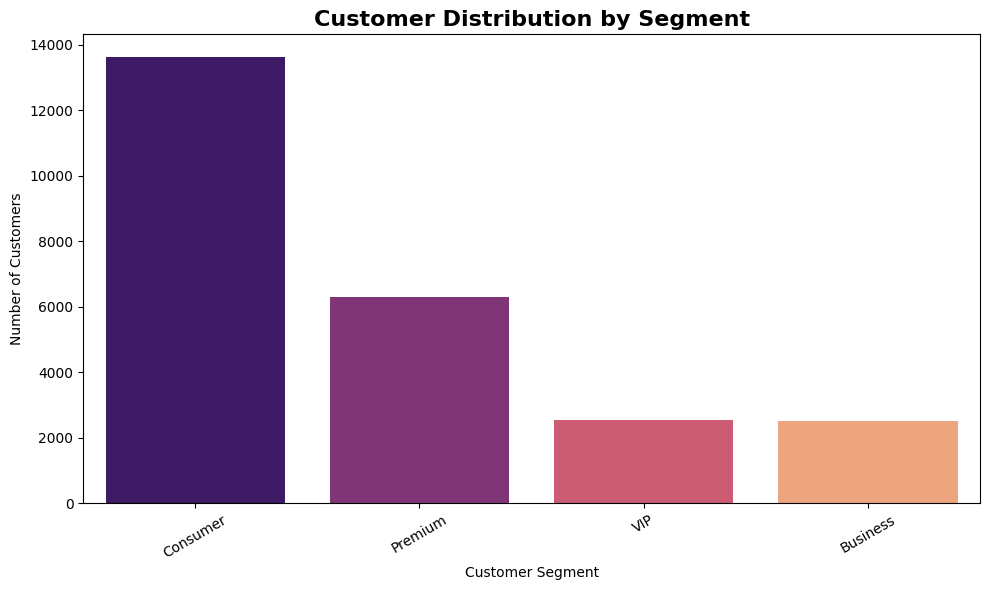

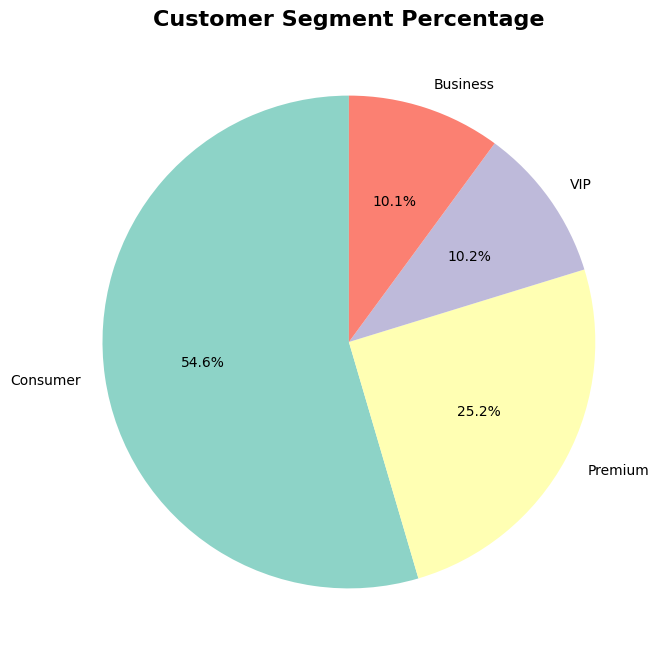

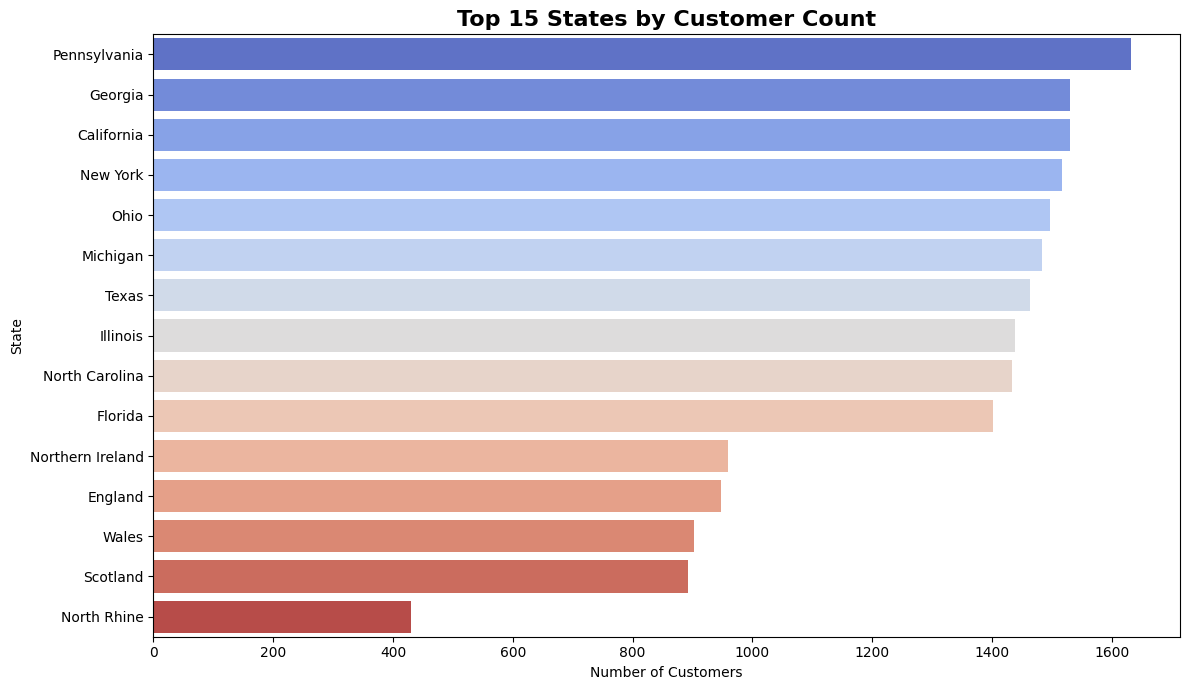

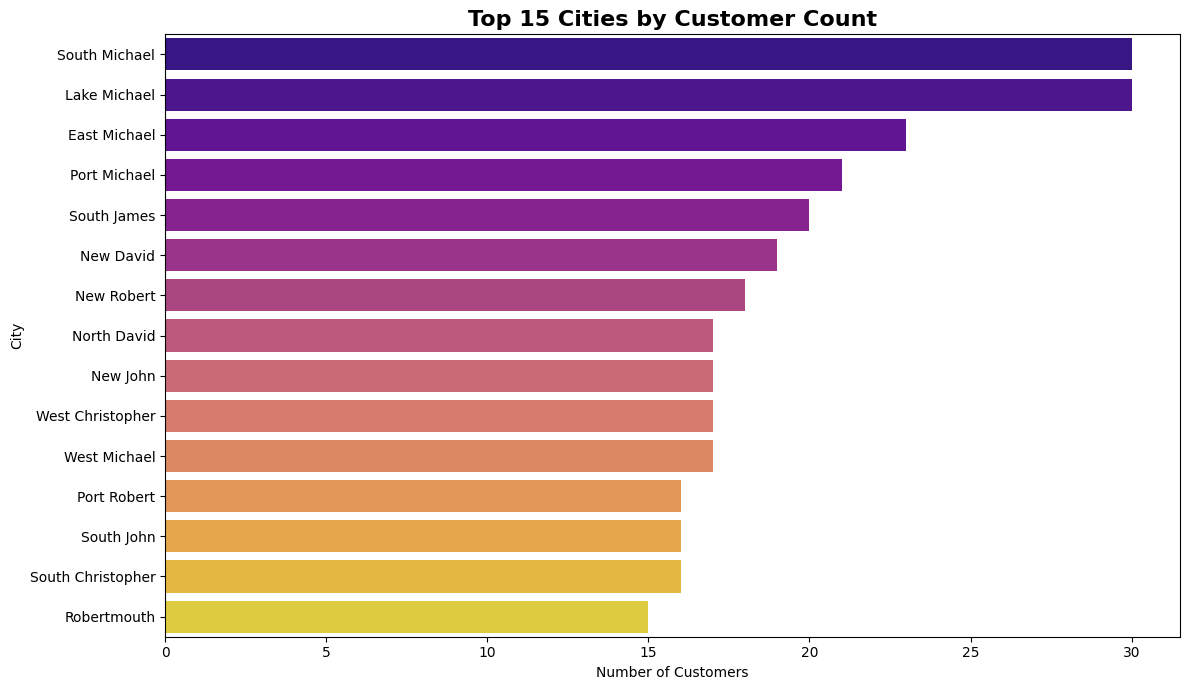

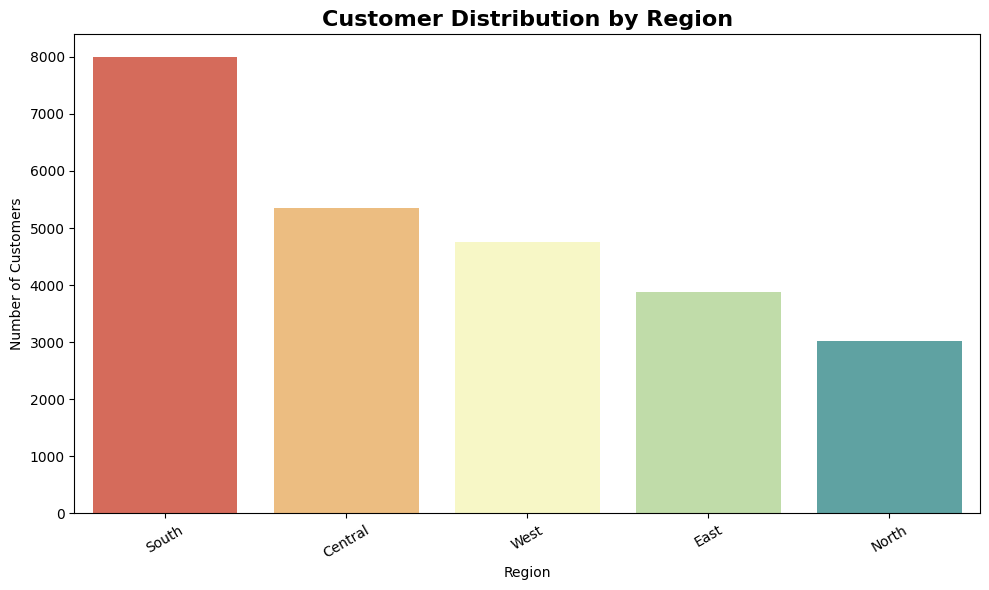

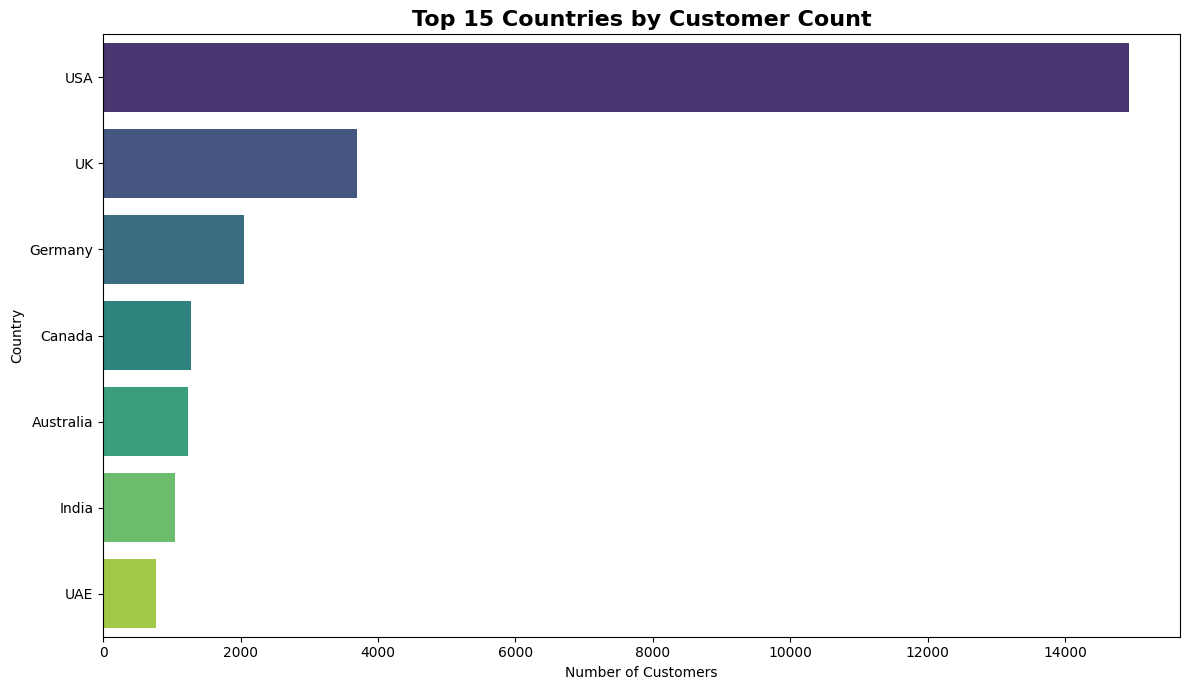

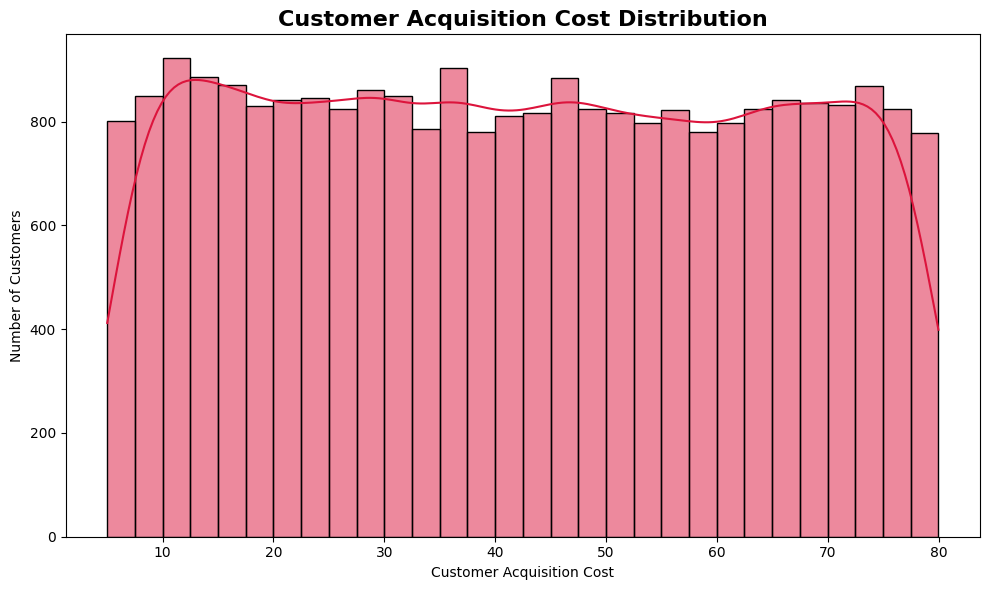

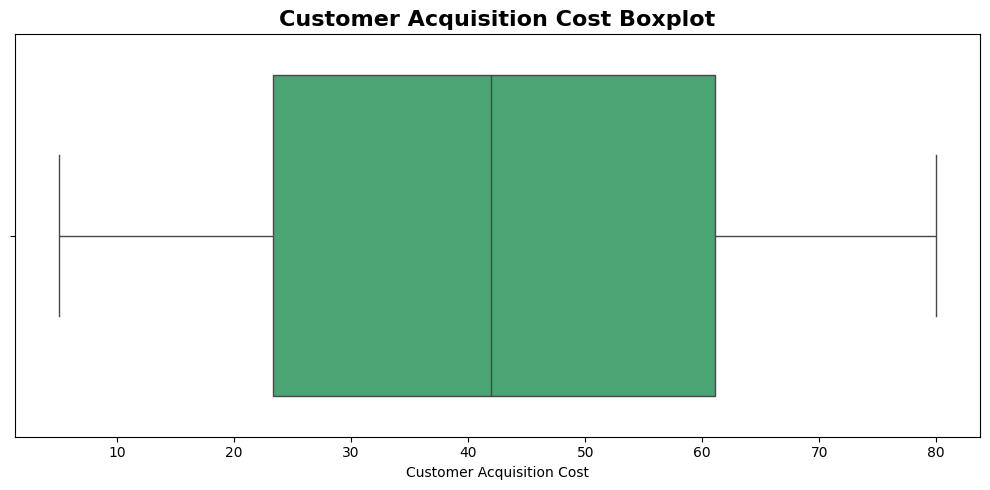

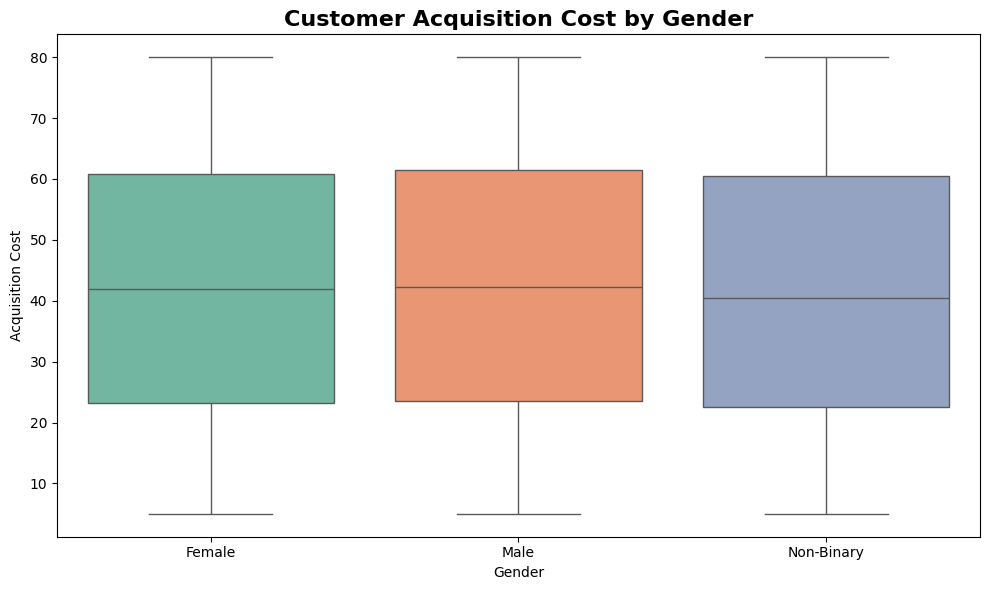

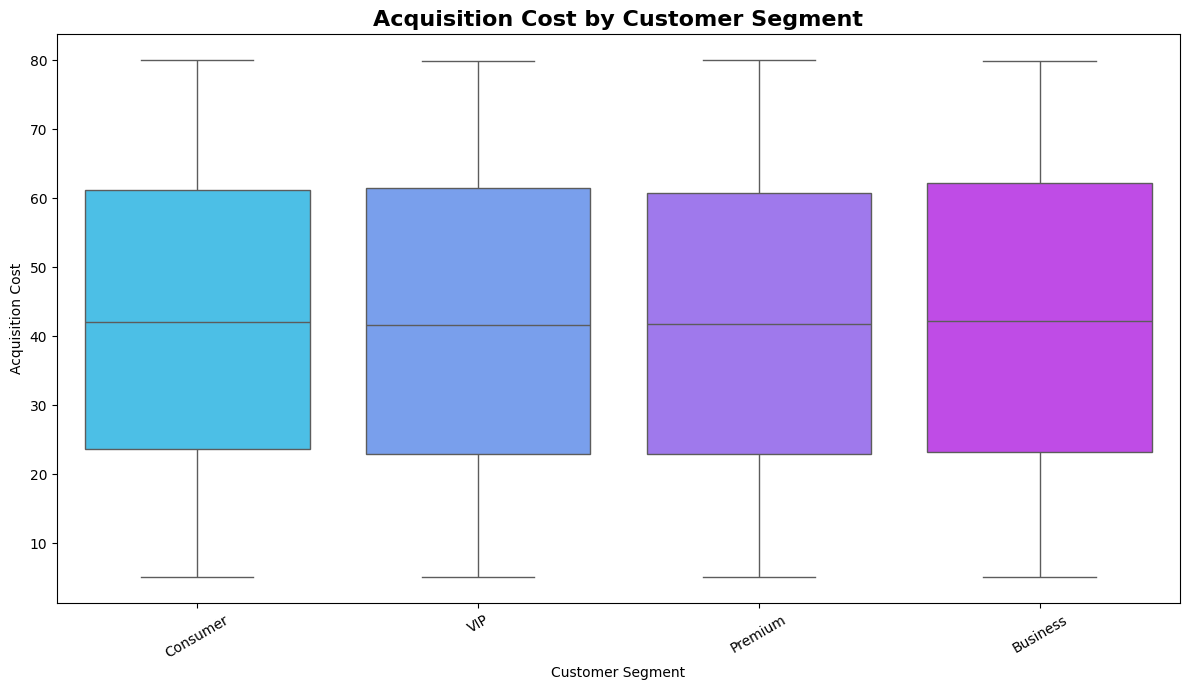

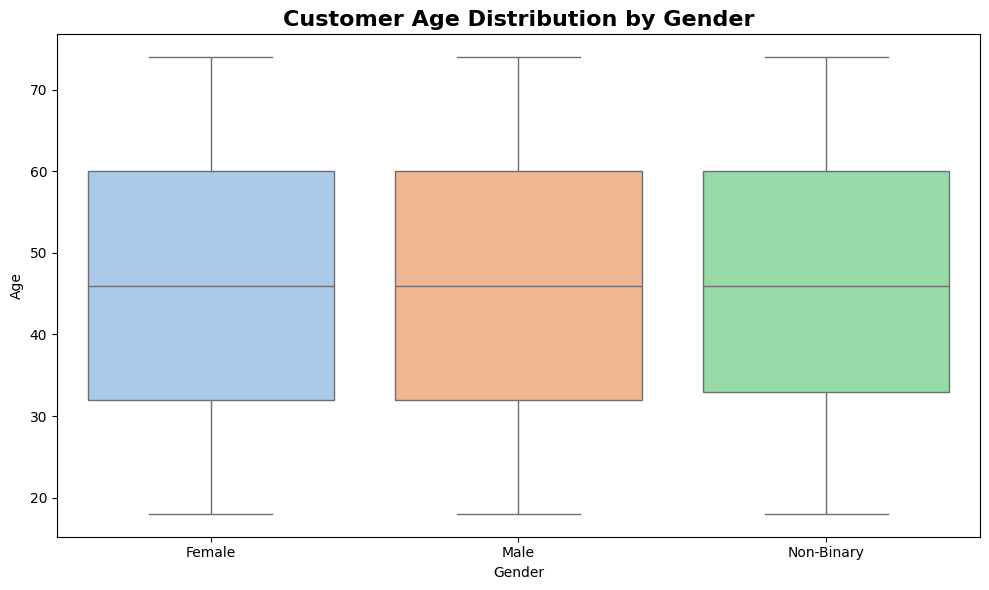

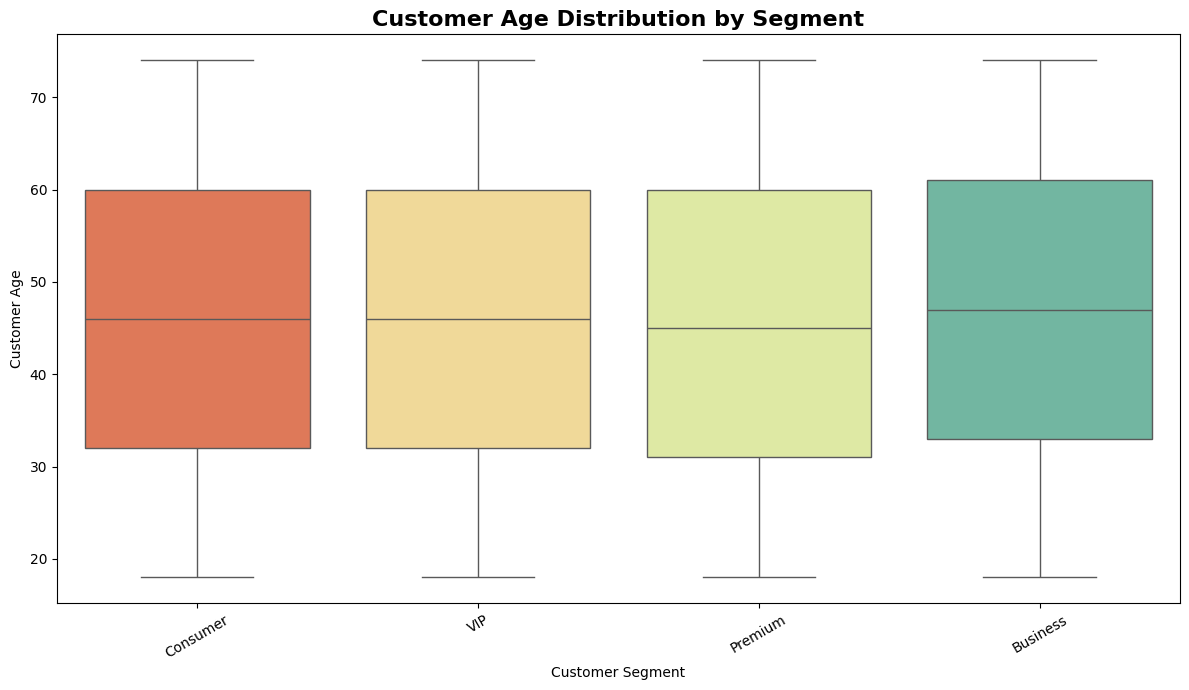

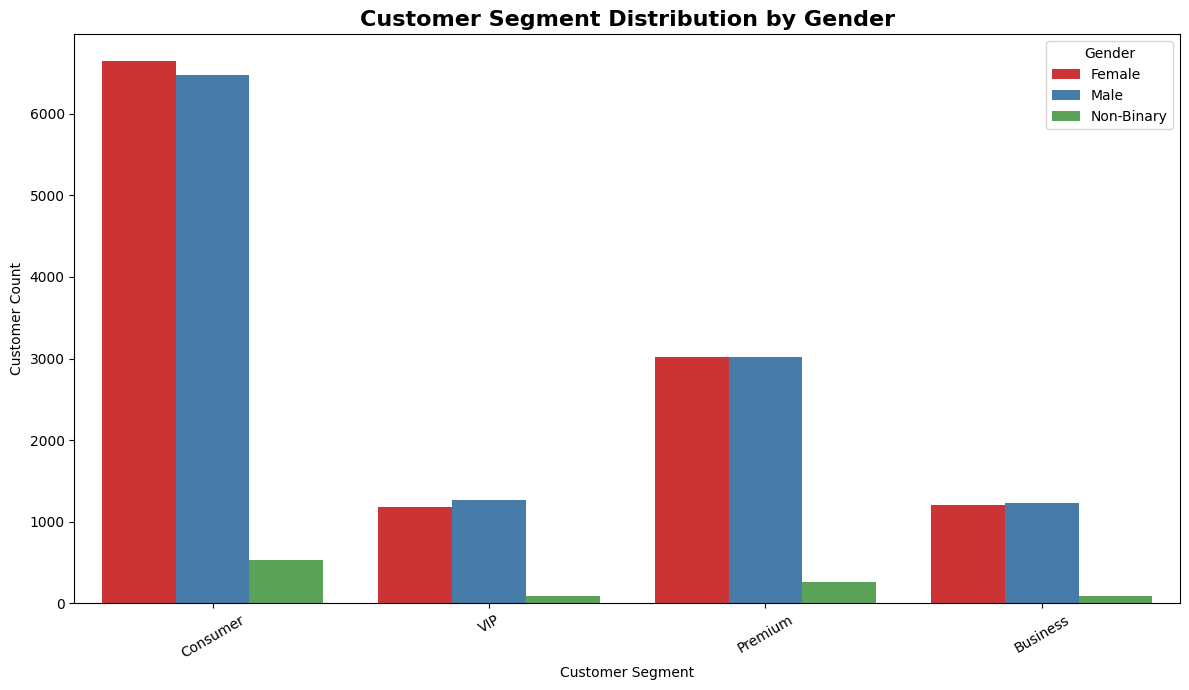

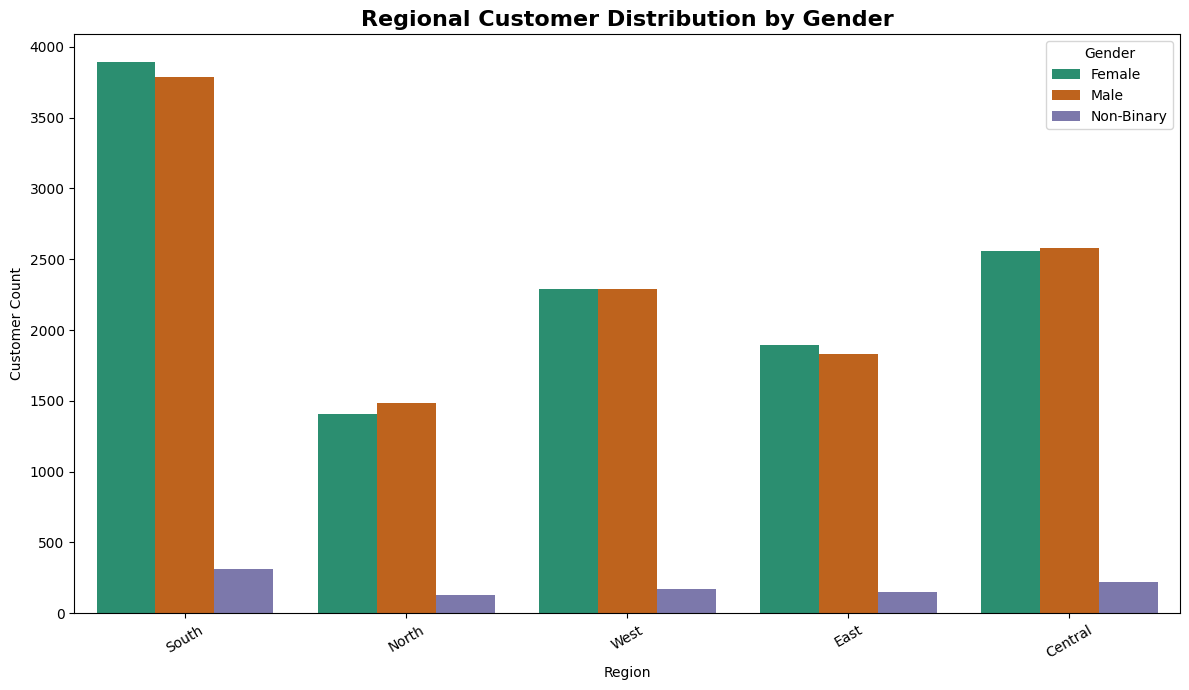

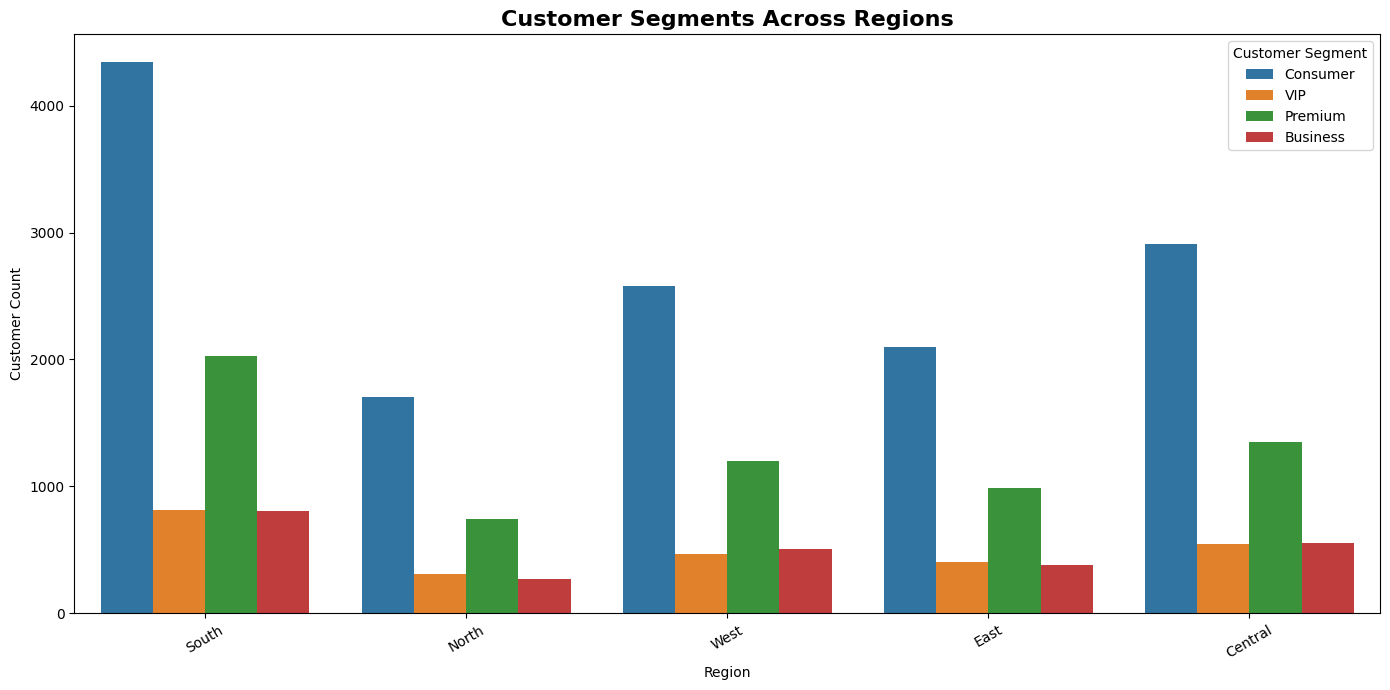

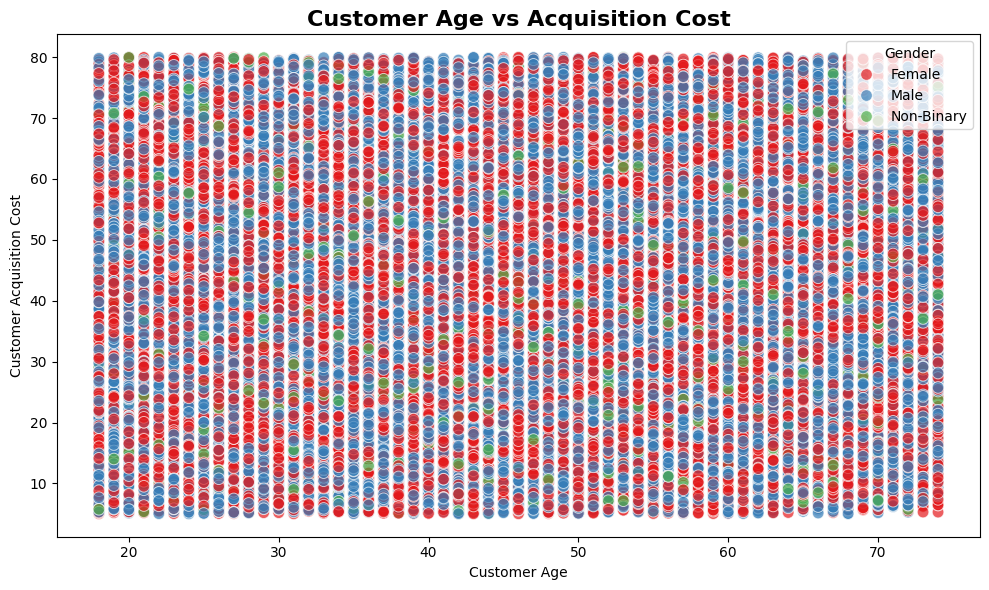

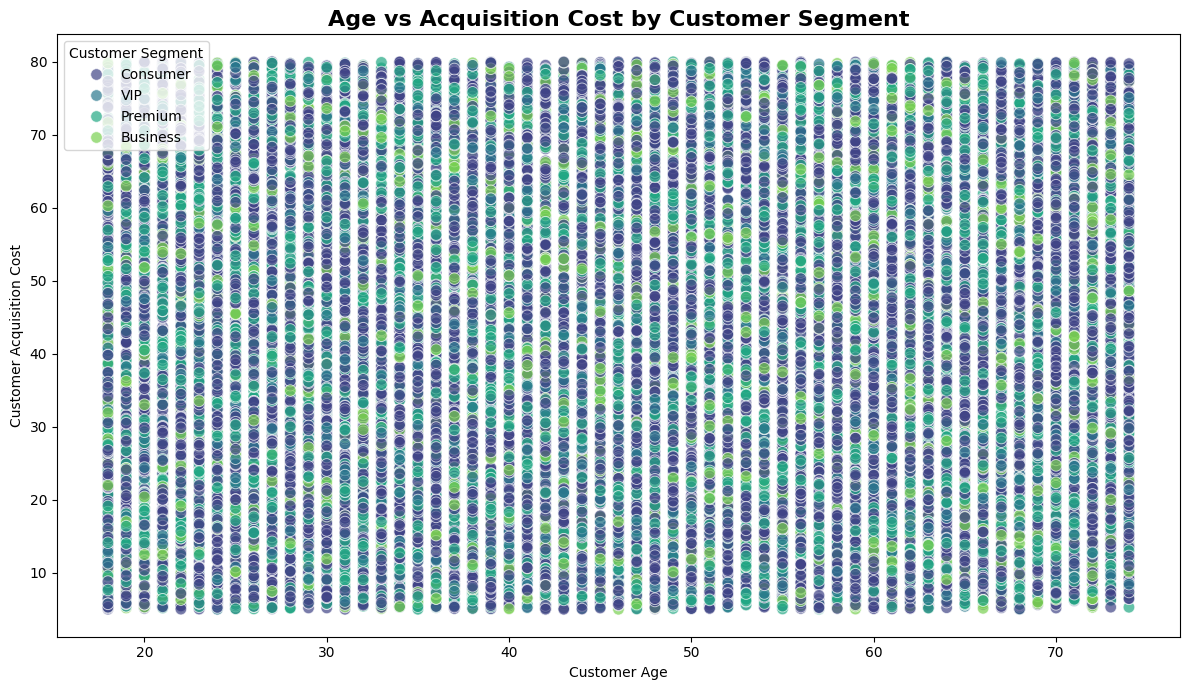

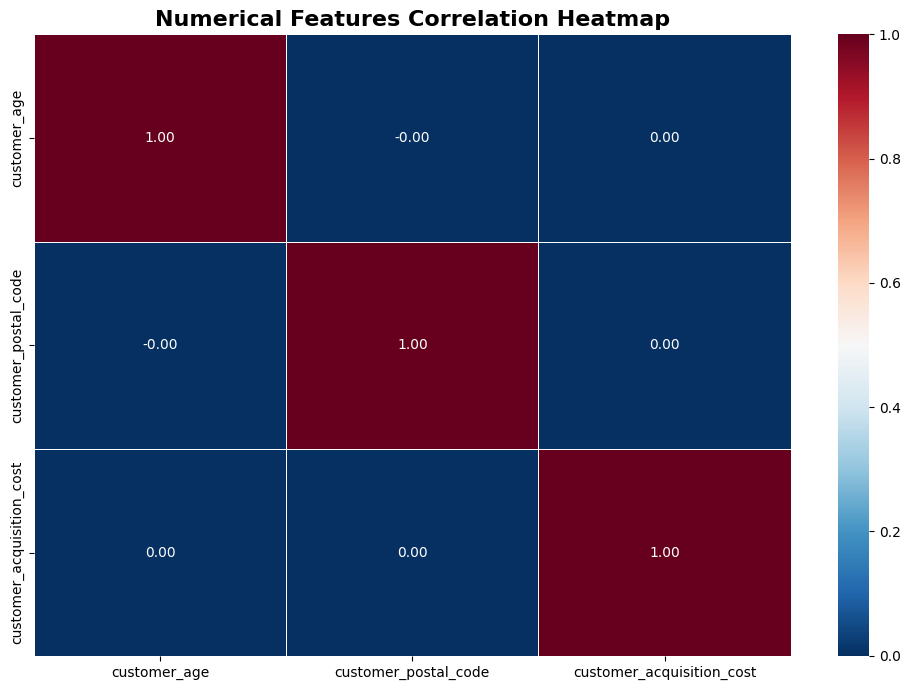

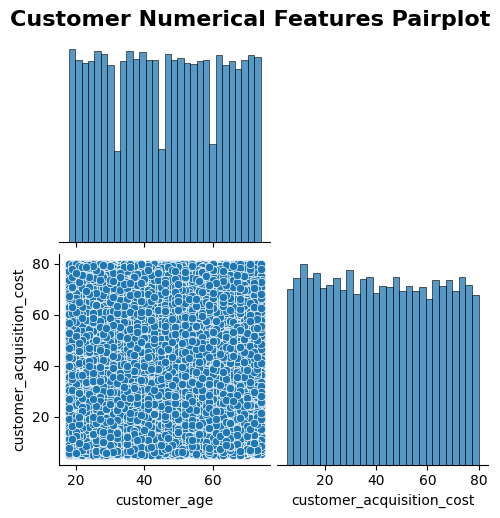

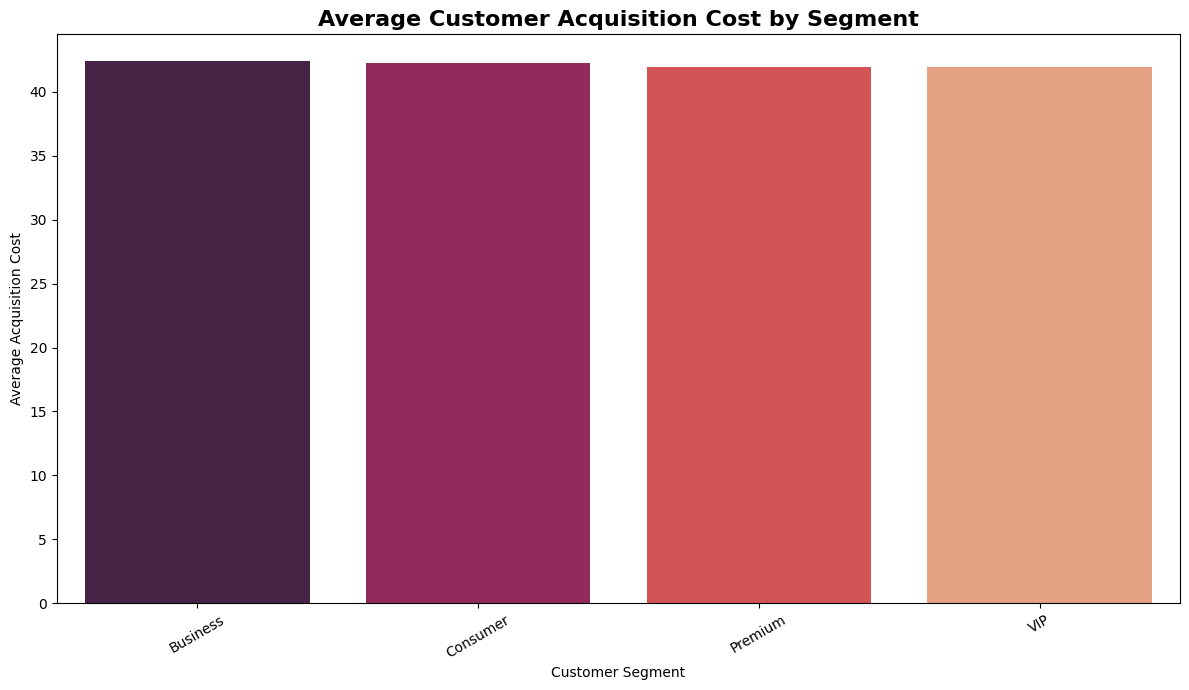

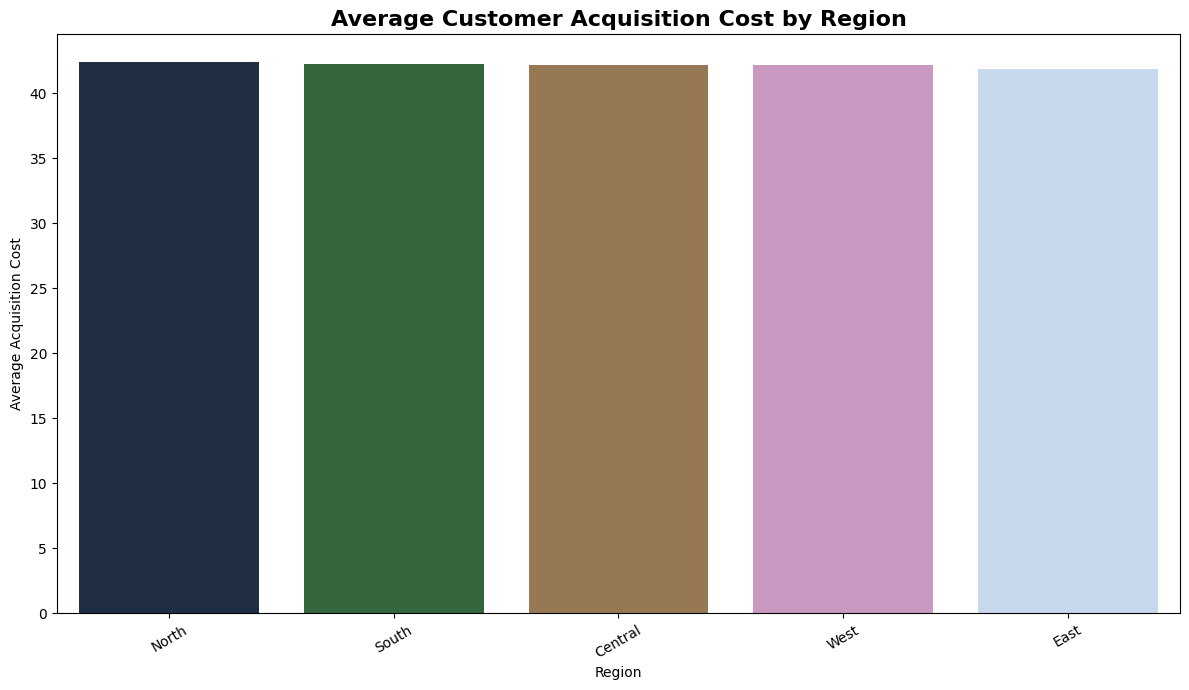

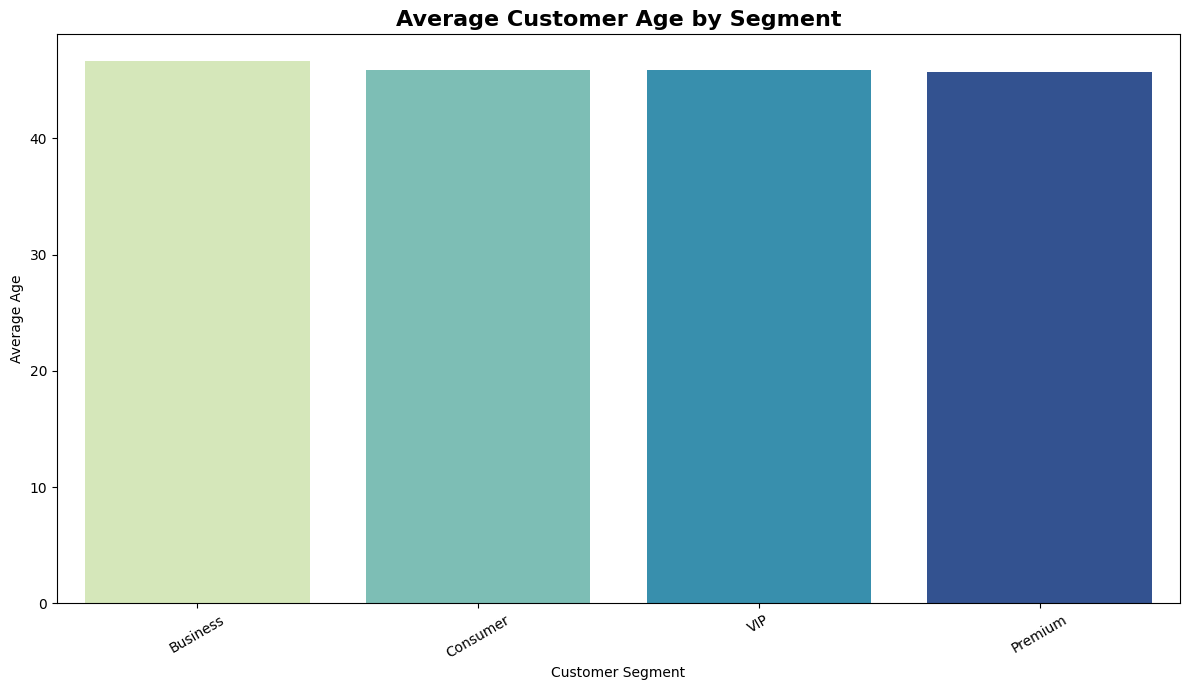

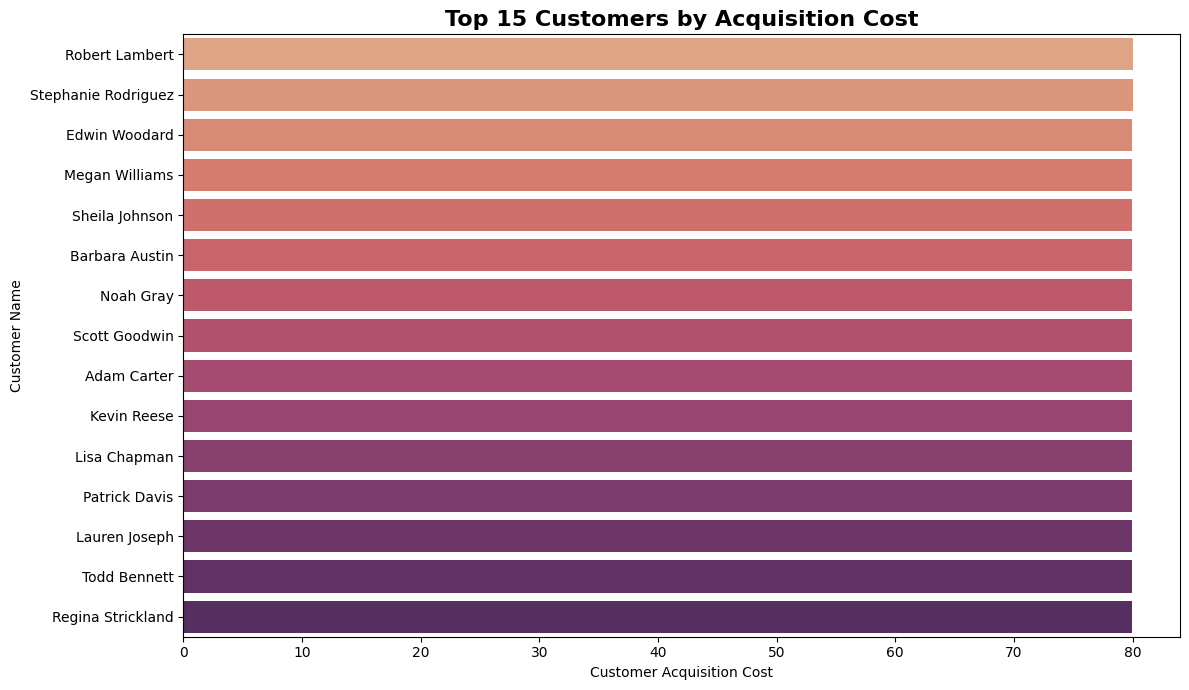

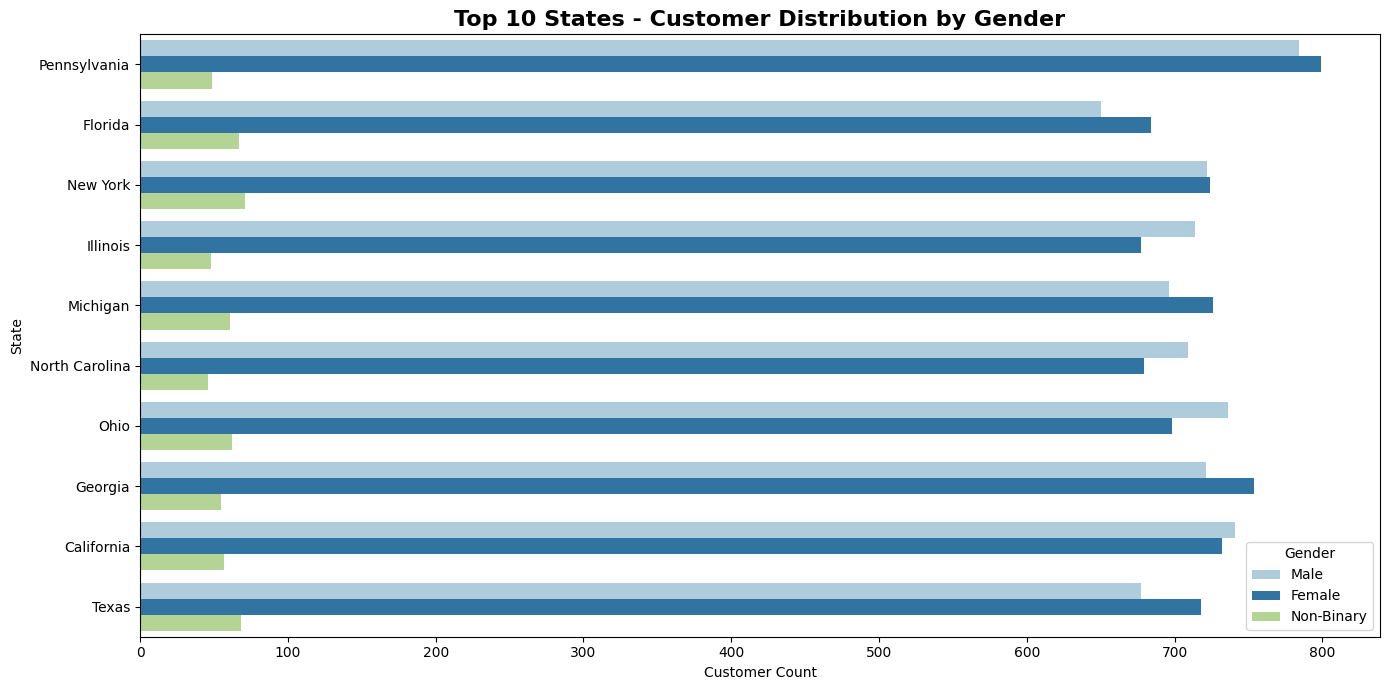


EDA SUMMARY
Total Customers       : 25000
Unique Customers      : 25000
Average Customer Age  : 45.91
Average Acquisition Cost : 42.16

Most Common Gender:
gender
Female    12048
Name: count, dtype: int64

Most Common Segment:
customer_segment
Consumer    13638
Name: count, dtype: int64

Most Common Region:
region
South    7996
Name: count, dtype: int64

Most Common State:
customer_state
Pennsylvania    1632
Name: count, dtype: int64

Most Common City:
customer_city
South Michael    30
Name: count, dtype: int64

EDA Visualization Completed Successfully!


In [14]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing.values,
        y=missing.index,
        palette="viridis"
    )

    plt.title("Missing Values by Column", fontsize=16, fontweight="bold")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Columns")
    plt.tight_layout()
    plt.show()

else:
    print("\nNo missing values found.")


# ============================================================
# 3. Customer Age Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="customer_age",
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Customer Age Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 4. Customer Age Boxplot
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["customer_age"],
    color="orange"
)

plt.title("Customer Age Boxplot", fontsize=16, fontweight="bold")
plt.xlabel("Customer Age")
plt.tight_layout()
plt.show()


# ============================================================
# 5. Gender Distribution
# ============================================================

gender_count = df["gender"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#6A5ACD", "#FF69B4", "#20B2AA", "#FFA500"]
)

plt.title("Customer Gender Distribution", fontsize=16, fontweight="bold")
plt.show()


# ============================================================
# 6. Gender Count
# ============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="gender",
    palette="Set2"
)

plt.title("Number of Customers by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()


# ============================================================
# 7. Customer Segment Distribution
# ============================================================

segment_count = df["customer_segment"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_count.index,
    y=segment_count.values,
    palette="magma"
)

plt.title("Customer Distribution by Segment", fontsize=16, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 8. Customer Segment Pie Chart
# ============================================================

plt.figure(figsize=(8, 8))

plt.pie(
    segment_count.values,
    labels=segment_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set3", len(segment_count))
)

plt.title("Customer Segment Percentage", fontsize=16, fontweight="bold")
plt.show()


# ============================================================
# 9. Customer State Distribution
# ============================================================

state_count = df["customer_state"].value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=state_count.values,
    y=state_count.index,
    palette="coolwarm"
)

plt.title("Top 15 States by Customer Count", fontsize=16, fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("State")
plt.tight_layout()
plt.show()


# ============================================================
# 10. Customer City Distribution
# ============================================================

city_count = df["customer_city"].value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=city_count.values,
    y=city_count.index,
    palette="plasma"
)

plt.title("Top 15 Cities by Customer Count", fontsize=16, fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("City")
plt.tight_layout()
plt.show()


# ============================================================
# 11. Region Distribution
# ============================================================

region_count = df["region"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_count.index,
    y=region_count.values,
    palette="Spectral"
)

plt.title("Customer Distribution by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 12. Country Distribution
# ============================================================

country_count = df["customer_country"].value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=country_count.values,
    y=country_count.index,
    palette="viridis"
)

plt.title("Top 15 Countries by Customer Count", fontsize=16, fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# ============================================================
# 13. Customer Acquisition Cost Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="customer_acquisition_cost",
    bins=30,
    kde=True,
    color="crimson"
)

plt.title(
    "Customer Acquisition Cost Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Acquisition Cost")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 14. Customer Acquisition Cost Boxplot
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["customer_acquisition_cost"],
    color="mediumseagreen"
)

plt.title(
    "Customer Acquisition Cost Boxplot",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Acquisition Cost")
plt.tight_layout()
plt.show()


# ============================================================
# 15. Acquisition Cost by Gender
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="gender",
    y="customer_acquisition_cost",
    palette="Set2"
)

plt.title(
    "Customer Acquisition Cost by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Acquisition Cost")
plt.tight_layout()
plt.show()


# ============================================================
# 16. Acquisition Cost by Customer Segment
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="customer_segment",
    y="customer_acquisition_cost",
    palette="cool"
)

plt.title(
    "Acquisition Cost by Customer Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Acquisition Cost")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 17. Customer Age by Gender
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="gender",
    y="customer_age",
    palette="pastel"
)

plt.title(
    "Customer Age Distribution by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


# ============================================================
# 18. Customer Age by Segment
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="customer_segment",
    y="customer_age",
    palette="Spectral"
)

plt.title(
    "Customer Age Distribution by Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Customer Age")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 19. Gender vs Customer Segment
# ============================================================

plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    x="customer_segment",
    hue="gender",
    palette="Set1"
)

plt.title(
    "Customer Segment Distribution by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=30)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


# ============================================================
# 20. Region vs Gender
# ============================================================

plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    x="region",
    hue="gender",
    palette="Dark2"
)

plt.title(
    "Regional Customer Distribution by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Customer Count")
plt.xticks(rotation=30)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


# ============================================================
# 21. Region vs Customer Segment
# ============================================================

plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    x="region",
    hue="customer_segment",
    palette="tab10"
)

plt.title(
    "Customer Segments Across Regions",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Customer Count")
plt.xticks(rotation=30)
plt.legend(title="Customer Segment")
plt.tight_layout()
plt.show()


# ============================================================
# 22. Age vs Acquisition Cost
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="customer_age",
    y="customer_acquisition_cost",
    hue="gender",
    palette="Set1",
    alpha=0.7,
    s=70
)

plt.title(
    "Customer Age vs Acquisition Cost",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Age")
plt.ylabel("Customer Acquisition Cost")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


# ============================================================
# 23. Age vs Acquisition Cost by Segment
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="customer_age",
    y="customer_acquisition_cost",
    hue="customer_segment",
    palette="viridis",
    alpha=0.7,
    s=70
)

plt.title(
    "Age vs Acquisition Cost by Customer Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Age")
plt.ylabel("Customer Acquisition Cost")
plt.legend(title="Customer Segment")
plt.tight_layout()
plt.show()


# ============================================================
# 24. Correlation Heatmap
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] > 1:

    plt.figure(figsize=(10, 7))

    correlation = numeric_df.corr()

    sns.heatmap(
        correlation,
        annot=True,
        cmap="RdBu_r",
        fmt=".2f",
        linewidths=0.5
    )

    plt.title(
        "Numerical Features Correlation Heatmap",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. Pairplot
# ============================================================

numeric_columns = [
    "customer_age",
    "customer_acquisition_cost"
]

available_columns = [
    col for col in numeric_columns
    if col in df.columns
]

if len(available_columns) >= 2:

    sns.pairplot(
        df[available_columns].dropna(),
        diag_kind="hist",
        corner=True
    )

    plt.suptitle(
        "Customer Numerical Features Pairplot",
        y=1.02,
        fontsize=16,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 26. Average Acquisition Cost by Segment
# ============================================================

segment_cost = (
    df.groupby("customer_segment")["customer_acquisition_cost"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=segment_cost.index,
    y=segment_cost.values,
    palette="rocket"
)

plt.title(
    "Average Customer Acquisition Cost by Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Acquisition Cost")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 27. Average Acquisition Cost by Region
# ============================================================

region_cost = (
    df.groupby("region")["customer_acquisition_cost"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=region_cost.index,
    y=region_cost.values,
    palette="cubehelix"
)

plt.title(
    "Average Customer Acquisition Cost by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Average Acquisition Cost")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 28. Average Age by Customer Segment
# ============================================================

segment_age = (
    df.groupby("customer_segment")["customer_age"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=segment_age.index,
    y=segment_age.values,
    palette="YlGnBu"
)

plt.title(
    "Average Customer Age by Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Age")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 29. Top 15 Customers by Acquisition Cost
# ============================================================

top_customers = (
    df.nlargest(15, "customer_acquisition_cost")
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_customers,
    x="customer_acquisition_cost",
    y="customer_name",
    palette="flare"
)

plt.title(
    "Top 15 Customers by Acquisition Cost",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Acquisition Cost")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show()


# ============================================================
# 30. Customer Count by State and Gender
# ============================================================

top_states = df["customer_state"].value_counts().head(10).index

state_gender = df[
    df["customer_state"].isin(top_states)
]

plt.figure(figsize=(14, 7))

sns.countplot(
    data=state_gender,
    y="customer_state",
    hue="gender",
    palette="Paired"
)

plt.title(
    "Top 10 States - Customer Distribution by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Count")
plt.ylabel("State")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


# ============================================================
# 31. Final EDA Summary
# ============================================================

print("\n" + "=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("Total Customers       :", len(df))
print("Unique Customers      :", df["customer_id"].nunique())
print("Average Customer Age  :", round(df["customer_age"].mean(), 2))
print(
    "Average Acquisition Cost :",
    round(df["customer_acquisition_cost"].mean(), 2)
)

print("\nMost Common Gender:")
print(df["gender"].value_counts().head(1))

print("\nMost Common Segment:")
print(df["customer_segment"].value_counts().head(1))

print("\nMost Common Region:")
print(df["region"].value_counts().head(1))

print("\nMost Common State:")
print(df["customer_state"].value_counts().head(1))

print("\nMost Common City:")
print(df["customer_city"].value_counts().head(1))

print("\nEDA Visualization Completed Successfully!")

## Feature engineering

DATASET INFORMATION
Shape: (25000, 11)

Columns:
Index(['customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code',
       'customer_acquisition_cost'],
      dtype='object')

Missing Values:
customer_id                  0
customer_name                0
customer_age                 0
gender                       0
customer_segment             0
customer_city                0
customer_state               0
customer_country             0
region                       0
customer_postal_code         0
customer_acquisition_cost    0
dtype: int64

Shape after removing duplicates: (25000, 11)

Target Variable: customer_segment

Target Distribution:
customer_segment
Consumer    13638
Premium      6301
VIP          2542
Business     2519
Name: count, dtype: int64

LABEL ENCODING
Original Classes:
['Business' 'Consumer' 'Premium' 'VIP']

Encoded Classes:
Business -> 0
Consumer 

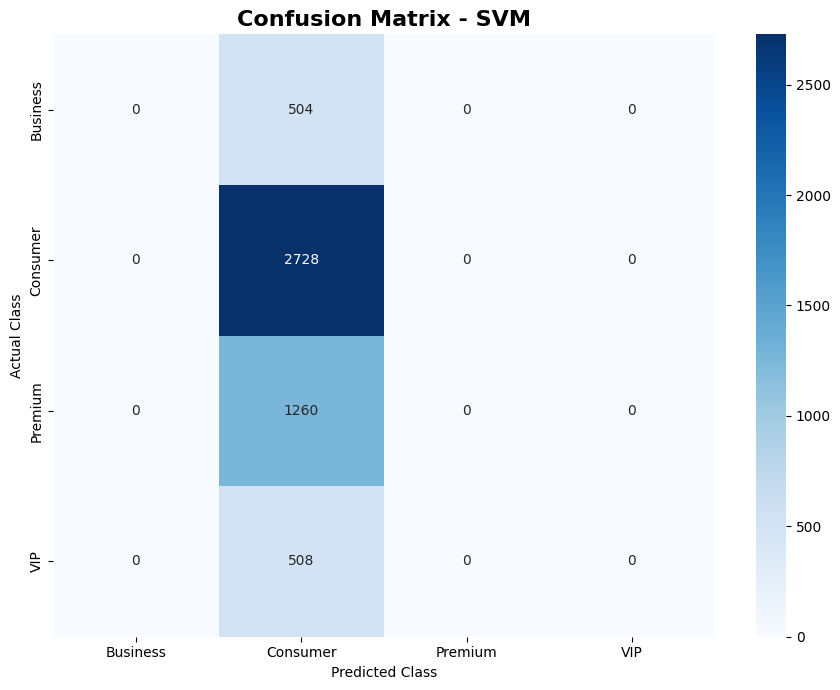

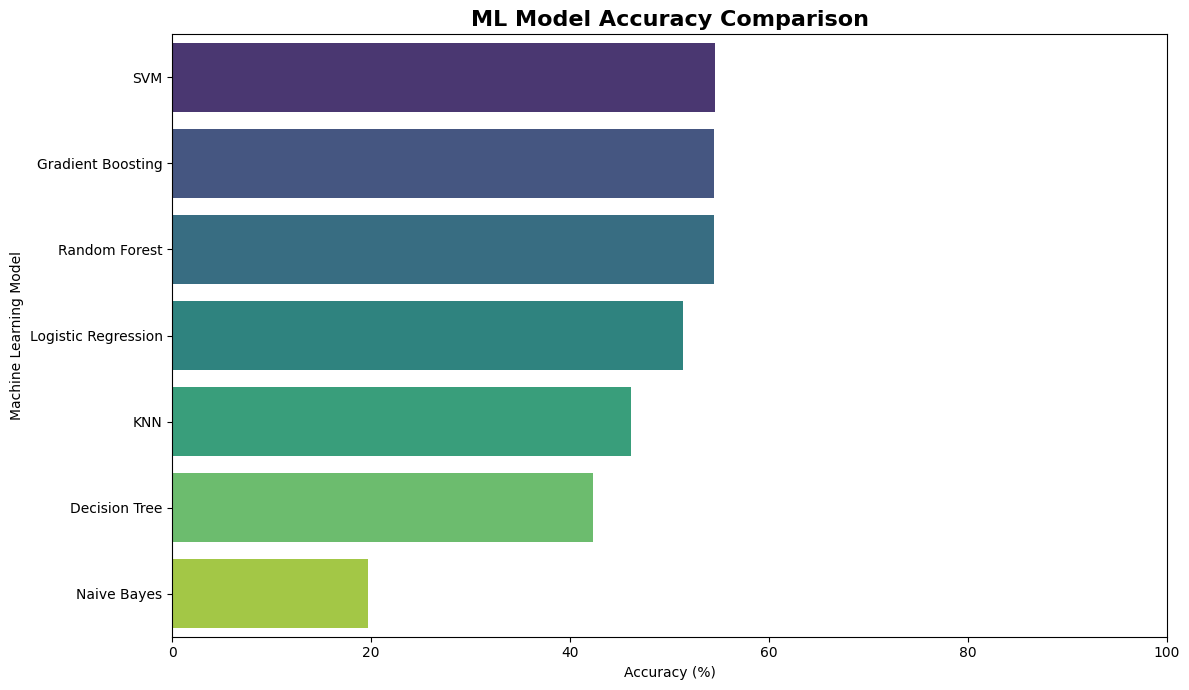

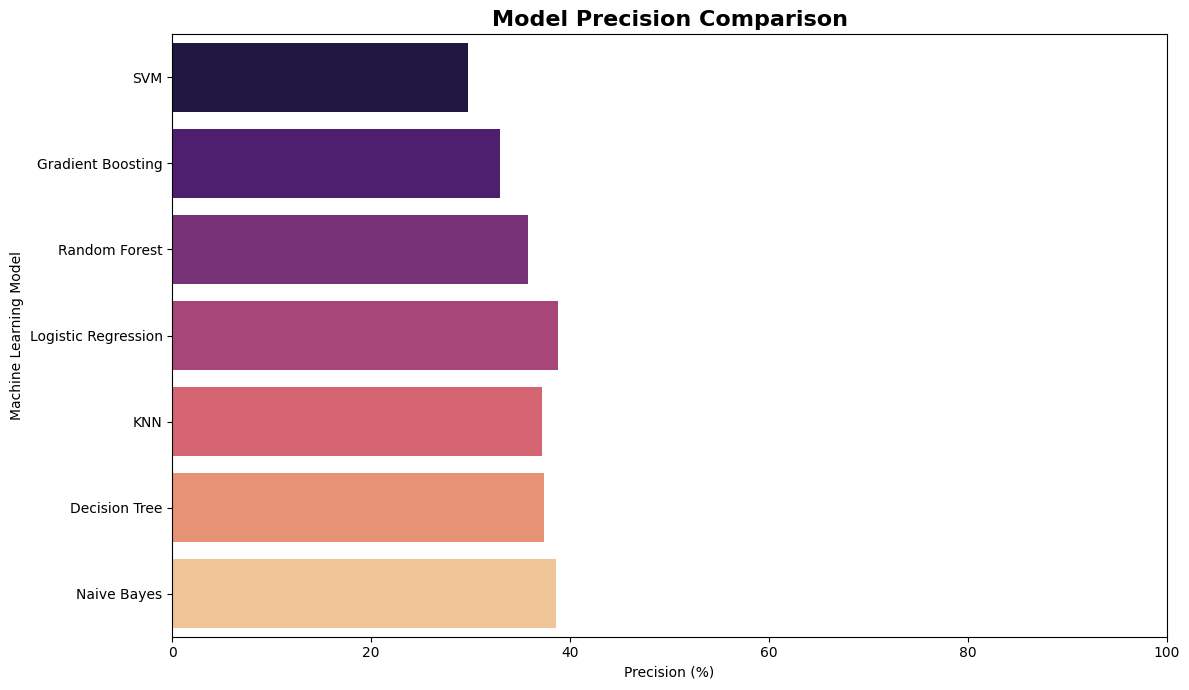

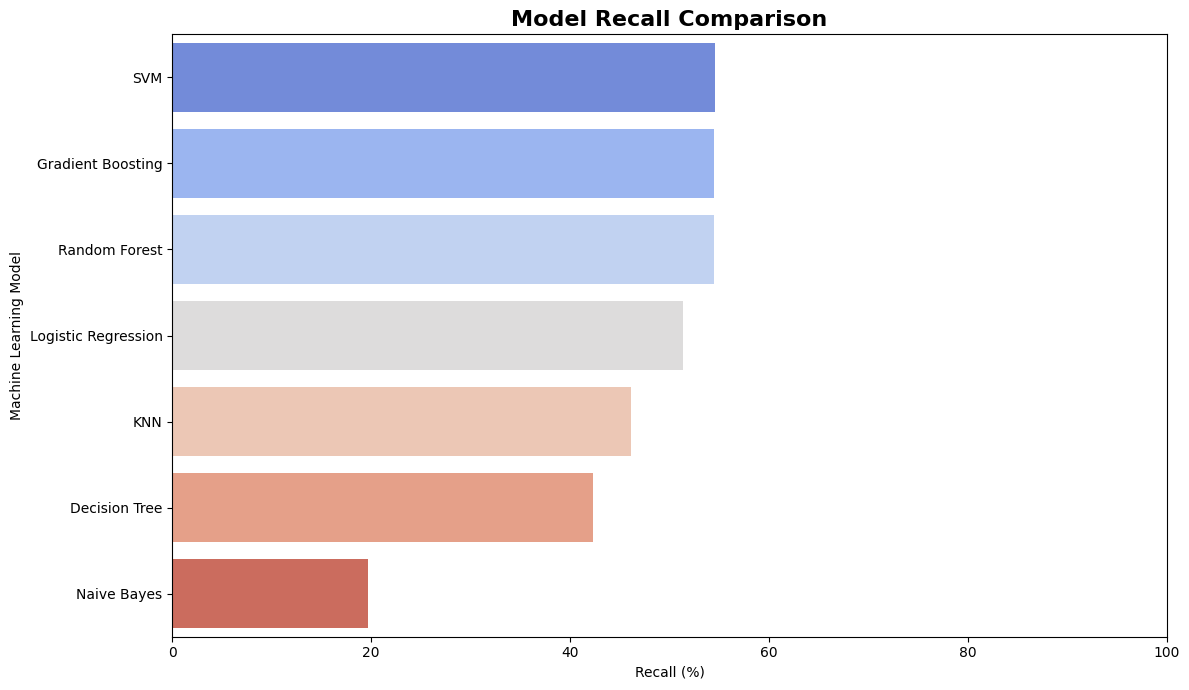

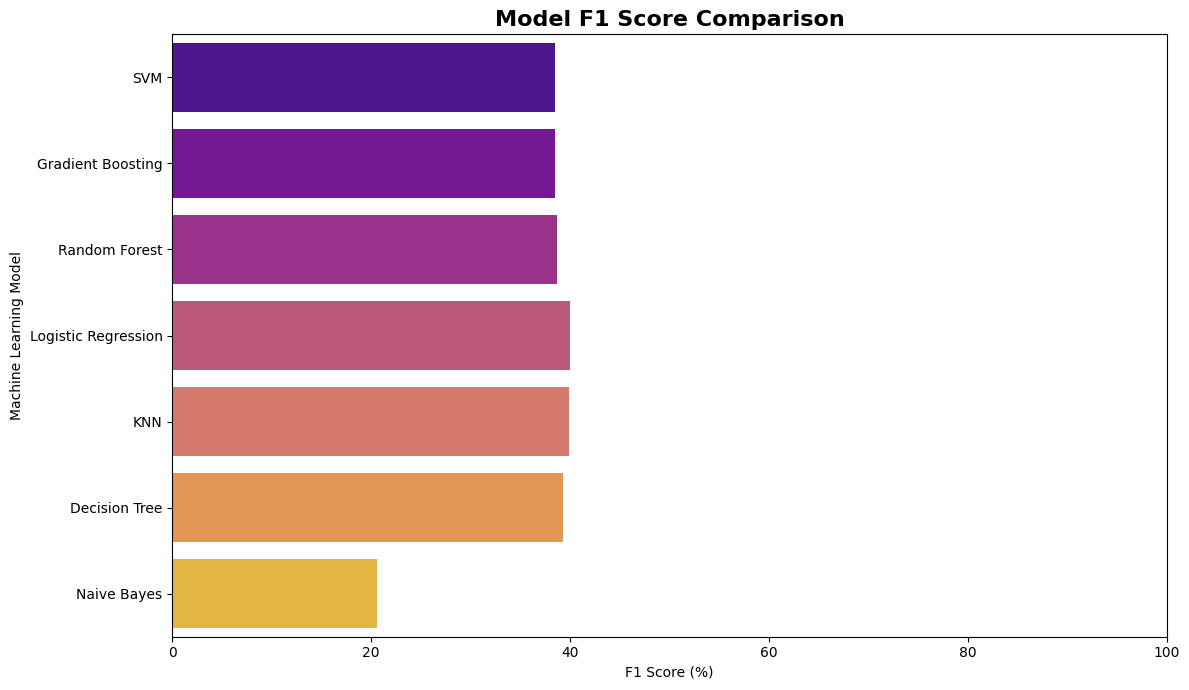

<Figure size 1500x800 with 0 Axes>

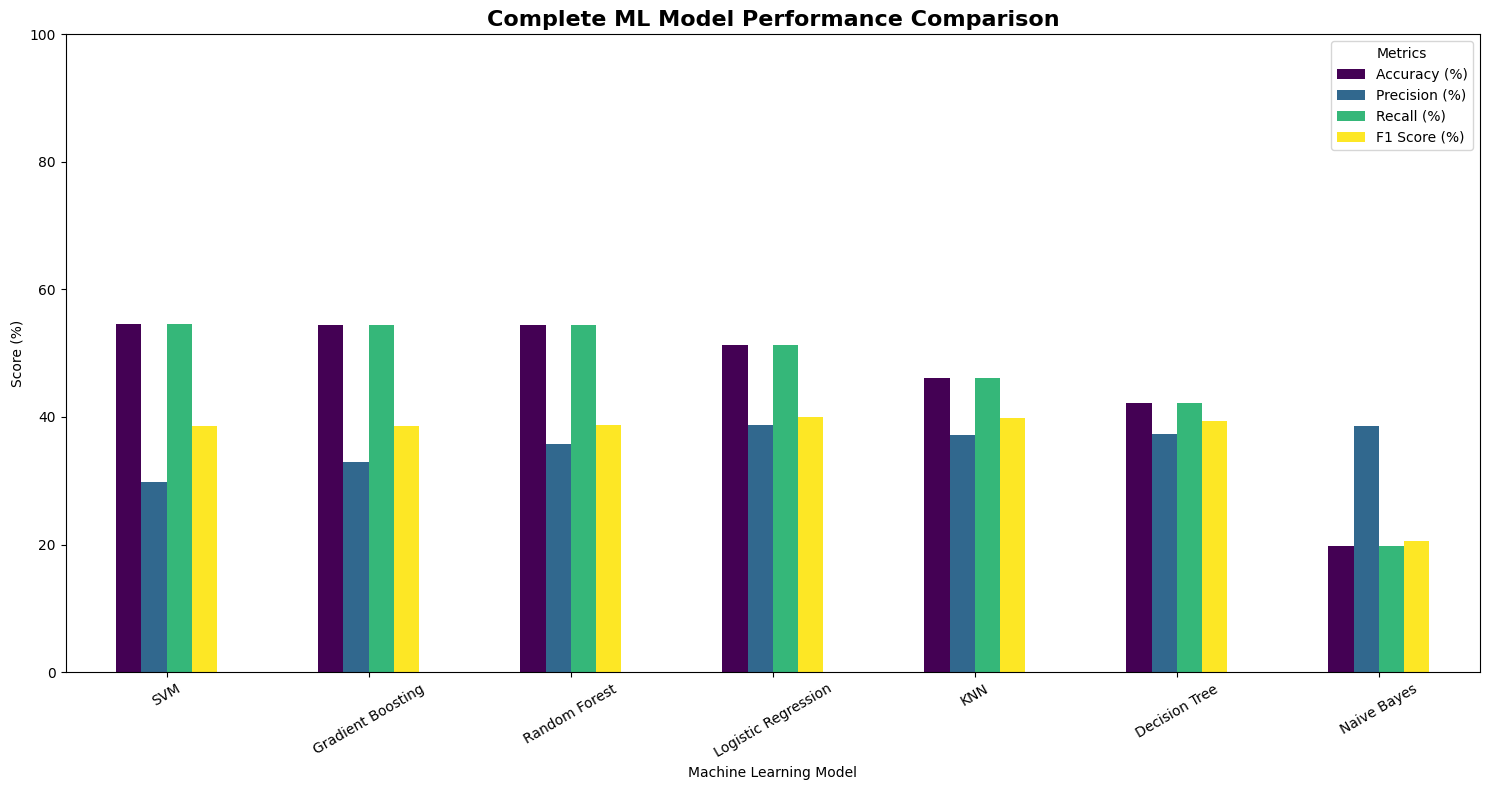


FINAL MODEL RESULTS
SVM                       Accuracy: 54.56% | Precision: 29.77% | Recall: 54.56% | F1: 38.52%
Gradient Boosting         Accuracy: 54.48% | Precision: 32.91% | Recall: 54.48% | F1: 38.53%
Random Forest             Accuracy: 54.42% | Precision: 35.79% | Recall: 54.42% | F1: 38.67%
Logistic Regression       Accuracy: 51.32% | Precision: 38.81% | Recall: 51.32% | F1: 40.02%
KNN                       Accuracy: 46.10% | Precision: 37.19% | Recall: 46.10% | F1: 39.88%
Decision Tree             Accuracy: 42.26% | Precision: 37.35% | Recall: 42.26% | F1: 39.32%
Naive Bayes               Accuracy: 19.70% | Precision: 38.62% | Recall: 19.70% | F1: 20.63%

BEST MODEL: SVM
BEST ACCURACY: 54.56%


In [15]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Column Transformer / Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. CHECK DATA
# ============================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)


# ============================================================
# 4. DEFINE TARGET
# ============================================================

# Target variable
target = "customer_segment"

print("\nTarget Variable:", target)

print("\nTarget Distribution:")
print(df[target].value_counts())


# ============================================================
# 5. REMOVE UNNECESSARY COLUMNS
# ============================================================

# These columns are identifiers/text identifiers and
# generally should not be used for prediction.

drop_columns = [
    "customer_id",
    "customer_name",
    "customer_segment"
]

X = df.drop(columns=drop_columns)

y = df[target]


# ============================================================
# 6. LABEL ENCODING - TARGET VARIABLE
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\n" + "=" * 70)
print("LABEL ENCODING")
print("=" * 70)

print("Original Classes:")
print(label_encoder.classes_)

print("\nEncoded Classes:")

for original, encoded in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(original, "->", encoded)


# ============================================================
# 7. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\n" + "=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 8. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\n" + "=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 9. PREPROCESSING
# ============================================================

# Numerical:
# - Fill missing values with median
# - StandardScaler

# Categorical:
# - Fill missing values with most frequent value
# - OneHotEncoder

from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)


# ============================================================
# 10. DEFINE ML MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf"
        ),

    "Naive Bayes":
        GaussianNB(),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}


# ============================================================
# 11. TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)

for model_name, model in models.items():

    print("\nTraining:", model_name)

    # Complete pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 Score (%)": f1 * 100
    })

    trained_models[model_name] = pipeline

    print(
        f"{model_name} Accuracy: "
        f"{accuracy * 100:.2f}%"
    )


# ============================================================
# 12. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy (%)": "{:.2f}".format,
            "Precision (%)": "{:.2f}".format,
            "Recall (%)": "{:.2f}".format,
            "F1 Score (%)": "{:.2f}".format
        }
    )
)


# ============================================================
# 13. BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Best Model:", best_model_name)

print(
    "Best Accuracy:",
    f"{results_df.iloc[0]['Accuracy (%)']:.2f}%"
)


# ============================================================
# 14. DETAILED CLASSIFICATION REPORT
# ============================================================

best_predictions = best_model.predict(X_test)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()


# ============================================================
# 16. ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Accuracy (%)",
    y="Model",
    palette="viridis"
)

plt.title(
    "ML Model Accuracy Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Model")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()


# ============================================================
# 17. PRECISION COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Precision (%)",
    y="Model",
    palette="magma"
)

plt.title(
    "Model Precision Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Precision (%)")
plt.ylabel("Machine Learning Model")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()


# ============================================================
# 18. RECALL COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Recall (%)",
    y="Model",
    palette="coolwarm"
)

plt.title(
    "Model Recall Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Recall (%)")
plt.ylabel("Machine Learning Model")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()


# ============================================================
# 19. F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="F1 Score (%)",
    y="Model",
    palette="plasma"
)

plt.title(
    "Model F1 Score Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("F1 Score (%)")
plt.ylabel("Machine Learning Model")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()


# ============================================================
# 20. ALL METRICS COMPARISON
# ============================================================

metrics_df = results_df.set_index("Model")[
    [
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)"
    ]
]

plt.figure(figsize=(15, 8))

metrics_df.plot(
    kind="bar",
    figsize=(15, 8),
    colormap="viridis"
)

plt.title(
    "Complete ML Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score (%)")

plt.ylim(0, 100)

plt.xticks(rotation=30)

plt.legend(
    title="Metrics"
)

plt.tight_layout()
plt.show()


# ============================================================
# 21. FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL RESULTS")
print("=" * 70)

for _, row in results_df.iterrows():

    print(
        f"{row['Model']:25s} "
        f"Accuracy: {row['Accuracy (%)']:.2f}% | "
        f"Precision: {row['Precision (%)']:.2f}% | "
        f"Recall: {row['Recall (%)']:.2f}% | "
        f"F1: {row['F1 Score (%)']:.2f}%"
    )

print("\n" + "=" * 70)

print(
    f"BEST MODEL: {best_model_name}"
)

print(
    f"BEST ACCURACY: "
    f"{results_df.iloc[0]['Accuracy (%)']:.2f}%"
)

print("=" * 70)

## Thank you..pls upvote!!!!!!!!!!!